# Data Exploration and Cleaning

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import AgglomerativeClustering

In [6]:
df = pd.read_csv('student-scores.csv')
df.head(5)

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [7]:
df.columns

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score'],
      dtype='object')

In [8]:
# Since id, name, email are unique values, I just dropped
new_df = df.drop(['id','first_name','last_name','email'], axis = 1)
new_df.head(5)

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [9]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   gender                      2000 non-null   object
 1   part_time_job               2000 non-null   bool  
 2   absence_days                2000 non-null   int64 
 3   extracurricular_activities  2000 non-null   bool  
 4   weekly_self_study_hours     2000 non-null   int64 
 5   career_aspiration           2000 non-null   object
 6   math_score                  2000 non-null   int64 
 7   history_score               2000 non-null   int64 
 8   physics_score               2000 non-null   int64 
 9   chemistry_score             2000 non-null   int64 
 10  biology_score               2000 non-null   int64 
 11  english_score               2000 non-null   int64 
 12  geography_score             2000 non-null   int64 
dtypes: bool(2), int64(9), object(2)
memory usage: 17

In [10]:
new_df.isnull().sum()

gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [11]:
new_df.columns

Index(['gender', 'part_time_job', 'absence_days', 'extracurricular_activities',
       'weekly_self_study_hours', 'career_aspiration', 'math_score',
       'history_score', 'physics_score', 'chemistry_score', 'biology_score',
       'english_score', 'geography_score'],
      dtype='object')

In [12]:
# Checking outliners
def outliers_detection(col):
    Q1 = new_df[col].quantile(0.25)
    Q3 = new_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5* IQR
    upper = Q3 + 1.5* IQR

    outliers = new_df[(new_df[col]<lower) | (df[col] >upper)]
    return outliers.shape[0]

print(f"Absence days outliers:", outliers_detection('absence_days'))
print(f"Self_study hour outliers:", outliers_detection('weekly_self_study_hours'))
print(f"Math Score outliers:", outliers_detection('math_score'))
print(f"History Score outliers:", outliers_detection('history_score'))
print(f"Physics Score outliers:", outliers_detection('physics_score'))
print(f"Chemistry Score outliers:", outliers_detection('chemistry_score'))
print(f"Biology Score outliers:", outliers_detection('biology_score'))
print(f"English Score outliers:", outliers_detection('english_score'))
print(f"Geography Score outliers:", outliers_detection('geography_score'))

Absence days outliers: 88
Self_study hour outliers: 0
Math Score outliers: 70
History Score outliers: 0
Physics Score outliers: 0
Chemistry Score outliers: 0
Biology Score outliers: 13
English Score outliers: 0
Geography Score outliers: 0


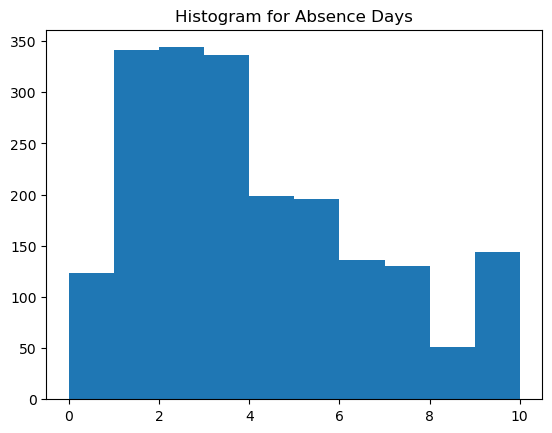

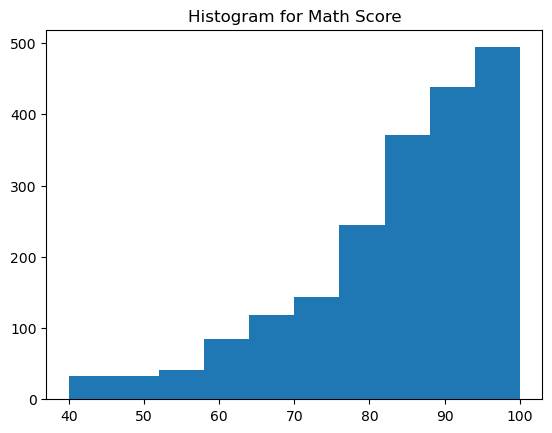

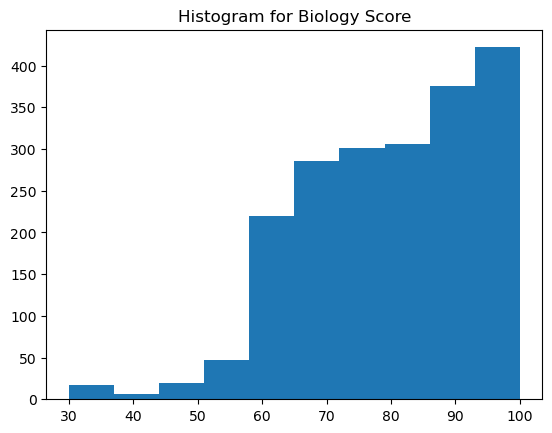

In [13]:
# Outliers Visualization 
new_df['absence_days'].hist(bins=10)
plt.title("Histogram for Absence Days")
plt.grid(False)
plt.show()

new_df['math_score'].hist(bins=10)
plt.title("Histogram for Math Score")
plt.grid(False)
plt.show()

new_df['biology_score'].hist(bins=10)
plt.title("Histogram for Biology Score")
plt.grid(False)
plt.show()


In [14]:
new_df.describe()

,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
std,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
min,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
25%,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000
50%,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000
75%,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000
max,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


Based on histogram visualization and data summary , the outliers are acceptable

# Data Preprocessing and Training

In [15]:
num_col = new_df.select_dtypes(include=['int64'])
cat_col = new_df.select_dtypes(include=['object','bool']).copy()

scaler = StandardScaler()
scaled_num_col = scaler.fit_transform(num_col)  

enc = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
encoded_cat_col = enc.fit_transform(cat_col) 

In [16]:
X_preprocessed = np.hstack([scaled_num_col, encoded_cat_col])
print("Shape of preprocessed data:", X_preprocessed.shape)

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X_preprocessed)

Shape of preprocessed data: (2000, 28)


In [17]:
agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X_preprocessed)

,n_clusters,None
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,0
,compute_distances,False


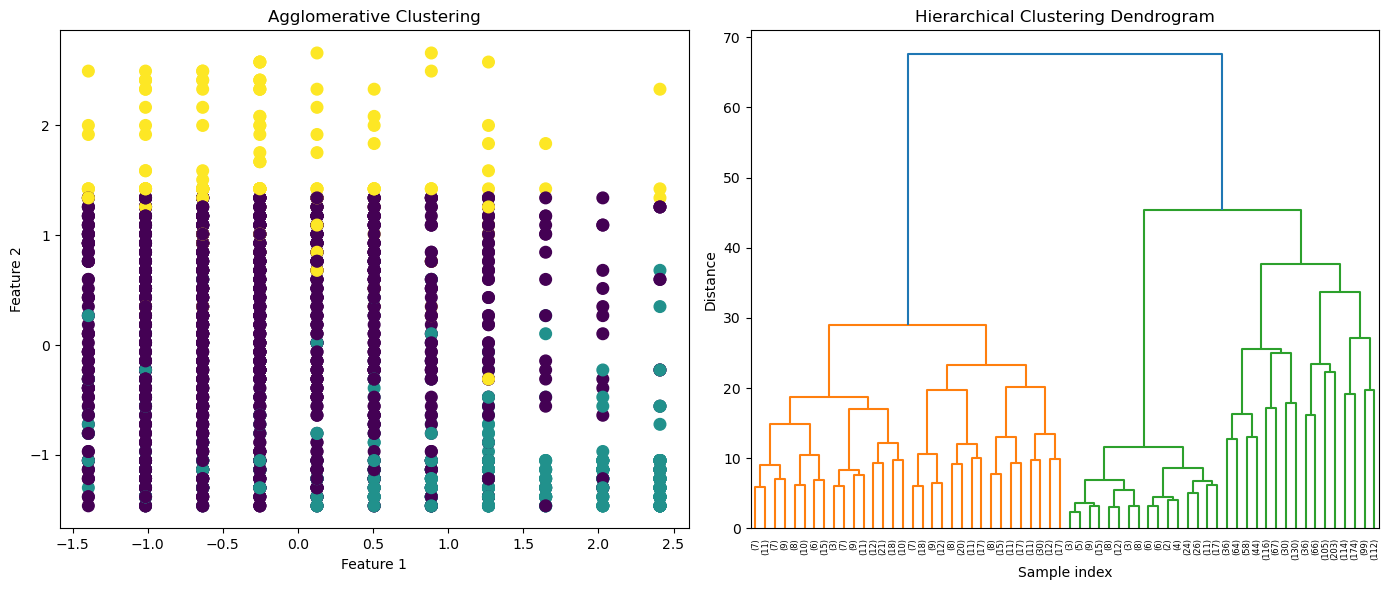

In [18]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X_preprocessed[:, 0], X_preprocessed[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()


Clusters: 2, Silhouette Score: 0.1715
Clusters: 3, Silhouette Score: 0.0584
Clusters: 4, Silhouette Score: 0.0442
Clusters: 5, Silhouette Score: 0.0415
Clusters: 6, Silhouette Score: 0.0422
Clusters: 7, Silhouette Score: 0.0386
Clusters: 8, Silhouette Score: 0.0370
Clusters: 9, Silhouette Score: 0.0383
Clusters: 10, Silhouette Score: 0.0414


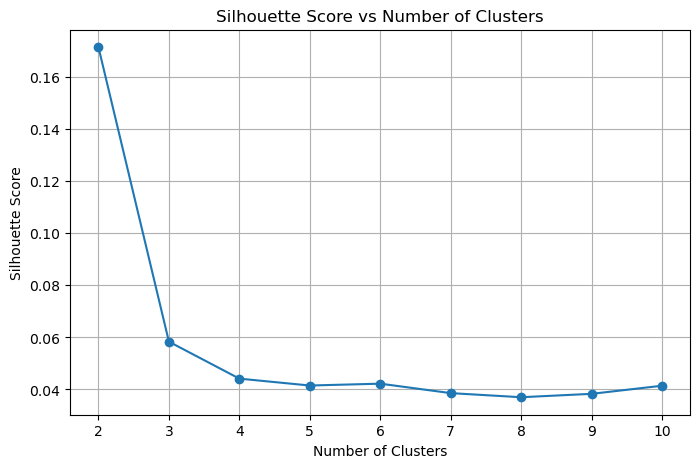

In [19]:
from sklearn.metrics import silhouette_score
cluster_range = range(2, 11)  

silhouette_scores = []

for n_clusters in cluster_range:
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X_preprocessed)
    
    sil_score = silhouette_score(X_preprocessed, labels)
    silhouette_scores.append(sil_score)
    print(f"Clusters: {n_clusters}, Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [20]:
best_n_clusters = cluster_range[np.argmax(silhouette_scores)]
print("Best number of clusters (Silhouette):", best_n_clusters)

Best number of clusters (Silhouette): 2


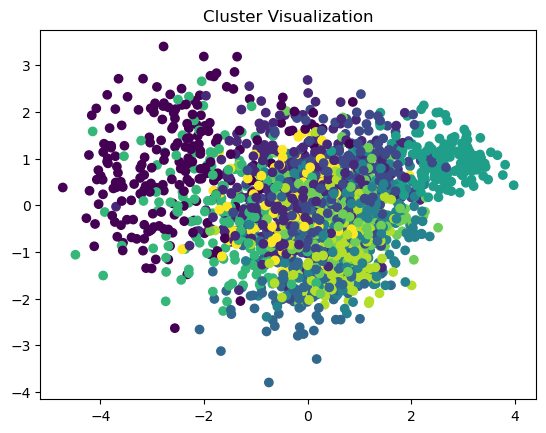

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_preprocessed)

plt.scatter(X_2d[:,0], X_2d[:,1], c=clustering.labels_, cmap='viridis')
plt.title("Cluster Visualization")
plt.show()

# Final Evaluation --> best cluster number is 2 

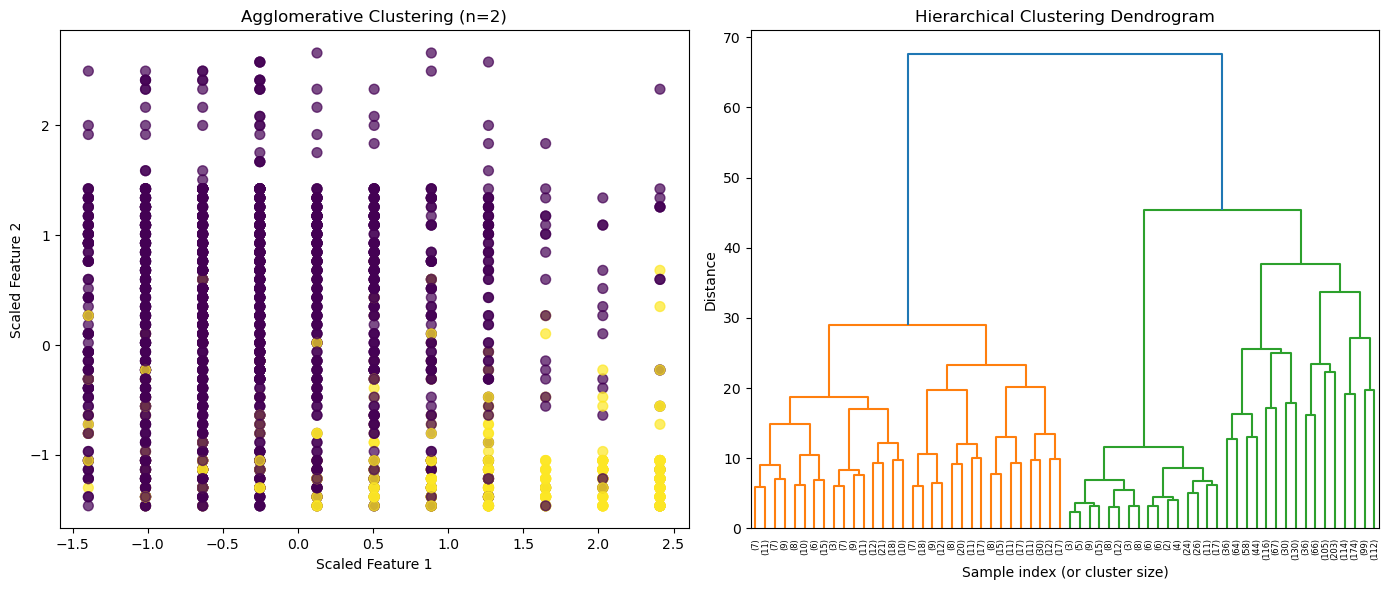

Model saved and plots generated.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from scipy.cluster.hierarchy import dendrogram
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering

# 1. Custom Dendrogram Function
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

# 2. Data Preparation
df = pd.read_csv('student-scores.csv')
df_clean = df.drop(columns=['id', 'first_name', 'last_name', 'email'])

numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df_clean.select_dtypes(include=['object', 'bool']).columns

# 3. Pipeline Construction
# Note: compute_distances=True is REQUIRED for the dendrogram to work
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

clustering_model = AgglomerativeClustering(n_clusters=2, compute_distances=True)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', clustering_model)
])

# 4. Execute
# Get preprocessed data for plotting and fit the model
X_preprocessed = pipeline.named_steps['preprocessor'].fit_transform(df_clean)
labels = pipeline.named_steps['clusterer'].fit_predict(X_preprocessed)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter Plot (using first two scaled features)
ax1.scatter(X_preprocessed[:, 0], X_preprocessed[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
ax1.set_title("Agglomerative Clustering (n=2)")
ax1.set_xlabel("Scaled Feature 1")
ax1.set_ylabel("Scaled Feature 2")

# Dendrogram
plt.sca(ax2)
plot_dendrogram(pipeline.named_steps['clusterer'], truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index (or cluster size)")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

# 6. Save Model
joblib.dump(pipeline, 'student_clustering_pipeline.pkl')
print("Model saved and plots generated.")

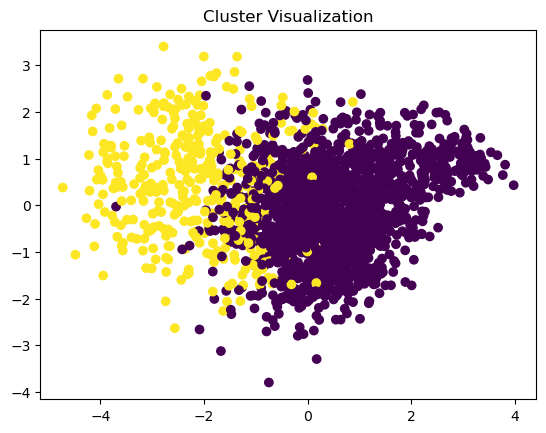

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_preprocessed)

plt.scatter(X_2d[:,0], X_2d[:,1], c=clustering_model.labels_, cmap='viridis')
plt.title("Cluster Visualization")
plt.show()

# PCA dropping 7 columns

In [24]:
df.columns

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score'],
      dtype='object')

In [25]:
import pandas as pd
import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA   

df = pd.read_csv('student-scores.csv')
df_clean = df.drop(columns=['id', 'first_name', 'last_name', 'email','gender','part_time_job','extracurricular_activities','career_aspiration'])

numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df_clean.select_dtypes(include=['object', 'bool']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

clustering_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),  
    ('clusterer', AgglomerativeClustering(n_clusters=3))
])

df['cluster_label'] = clustering_pipeline.fit_predict(df_clean)


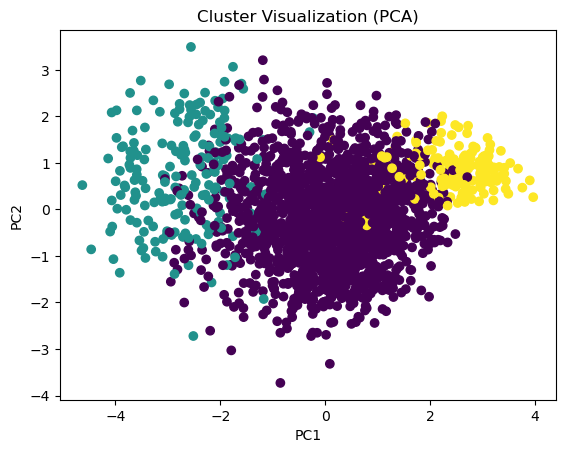

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_processed = clustering_pipeline.named_steps['preprocessor'].transform(df_clean)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_processed)

labels = clustering_pipeline.named_steps['clusterer'].labels_

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Clusters: 2, Silhouette Score: 0.3115
Clusters: 3, Silhouette Score: 0.3217
Clusters: 4, Silhouette Score: 0.3182
Clusters: 5, Silhouette Score: 0.2630
Clusters: 6, Silhouette Score: 0.2711
Clusters: 7, Silhouette Score: 0.2750
Clusters: 8, Silhouette Score: 0.2731
Clusters: 9, Silhouette Score: 0.2675
Clusters: 10, Silhouette Score: 0.2713


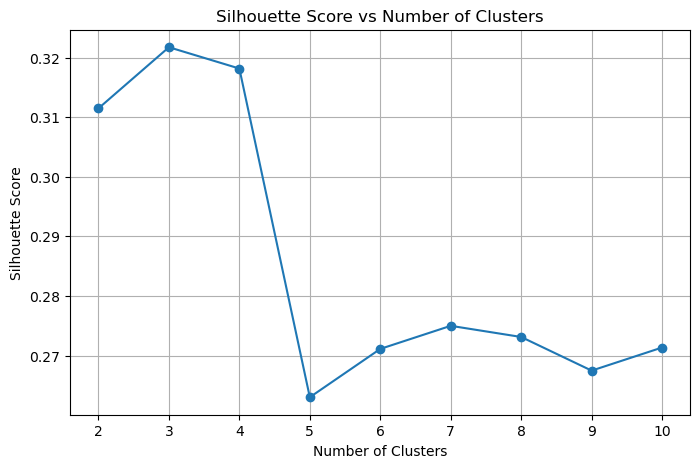

In [27]:
from sklearn.metrics import silhouette_score
cluster_range = range(2, 11)  

silhouette_scores = []

for n_clusters in cluster_range:
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X_2d)
    
    sil_score = silhouette_score(X_2d, labels)
    silhouette_scores.append(sil_score)
    print(f"Clusters: {n_clusters}, Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [28]:
import pandas as pd
print(pd.__version__)

2.3.3
